# Project Title:
## Global Market Linkages and Shock Transmission: A Time Series Analysis of US and Indian Equity Markets

---

## Details
- **Subject:** Analysis and Forecast of Time Series
- **Guide:** Prof. Leena Kulkarni
- **Semester:** II  
- **Group Number:** 4  

### Team Members
- Viral Kariya – A045
- Vanshika Ahuja – A022
- Mahat Vasudev – A008
- Avinashi Vora – A021
- Yash Shekhar – A00

---

## Introduction

Financial markets across the world are increasingly interconnected. Movements in major markets, particularly the United States, often influence emerging markets such as India through capital flows, investor sentiment, and global risk factors.

Understanding these relationships is important for portfolio management, risk assessment, and policy decisions. This project explores how the US and Indian equity markets are linked, and how global macro-financial variables contribute to this relationship.


---

## Research Objectives

This project addresses the following key research questions:

#### 1. Do the US and Indian equity markets move together in the long run?
#### 2. Does the US market influence the Indian market in the short run?
#### 3. Do global macro-financial factors such as VIX, BRENT, and DXY influence equity markets?
#### 4. How quickly does the Indian market respond to shocks originating from the US market?
#### 5. Does the Indian market react differently to increases and declines in the US market?
#### 6. Does the relationship change during the Israel–US vs Iran war period?

---

## Data Description

The analysis uses daily data from 2007 to 2025. The dataset includes:

| Variable | Description |
|----------|------------|
| SP500 | US equity market index |
| NIFTY | Indian equity market index |
| USDINR | Exchange rate |
| VIX | Market volatility index |
| BRENT | Crude oil prices |
| DXY | US Dollar Index |

These variables capture both equity market behavior and broader global financial conditions.


---

## Code Setup

### Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM

### Configuration

In [2]:
# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

### User-Defined Functions

In [3]:
import sys
sys.path.append('../')

In [4]:
from src.fetch_data import fetch_data
from src.adf_test import run_adf_test
from src.returns import transform_to_returns
from src.johansen_test import cointegration_test
from src.granger_test import granger_test
from src.irf_plot import plot_irf_relationship
from src.plot_asymmetric import plot_asymmetric_response

### Load Data

In [5]:
data = fetch_data()

In [6]:
data.head()

,SP500,NIFTY,USDINR,VIX,BRENT,DXY
Date,,,,,,
2007-09-17,1476.650024,4494.649902,40.376999,26.480000,76.980003,79.720001
2007-09-18,1519.780029,4546.200195,40.216999,20.350000,77.589996,79.209999
2007-09-19,1529.030029,4732.350098,40.033001,20.030001,78.470001,79.300003
2007-09-20,1518.750000,4747.549805,39.615002,20.450001,79.089996,78.580002
2007-09-21,1525.750000,4837.549805,39.770000,19.000000,79.300003,78.599998


### Quick Check

In [7]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4834 entries, 2007-09-17 to 2026-03-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SP500   4834 non-null   float64
 1   NIFTY   4834 non-null   float64
 2   USDINR  4834 non-null   float64
 3   VIX     4834 non-null   float64
 4   BRENT   4834 non-null   float64
 5   DXY     4834 non-null   float64
dtypes: float64(6)
memory usage: 264.4 KB


In [8]:
data.describe()

,SP500,NIFTY,USDINR,VIX,BRENT,DXY
count,4834.000000,4834.000000,4834.000000,4834.000000,4834.000000,4834.000000
mean,2772.536083,11057.632714,65.058982,19.936746,78.177942,91.051597
std,1580.671831,6478.949483,14.001622,8.805730,23.890984,10.059291
min,676.530029,2524.199951,39.044998,9.140000,19.330000,71.330002
25%,1408.682526,5691.074829,52.852499,14.152500,61.060001,80.742498
50%,2258.800049,8745.300293,66.248001,17.590000,75.550003,93.760002
75%,3934.717529,15817.362549,74.976925,22.855000,98.359999,98.597498
max,6978.600098,26328.550781,94.781799,82.690002,146.080002,114.110001


---
---

## Objective 1: Long-run Relationship between US and Indian Markets

We begin by examining whether the US (SP500) and Indian (NIFTY) markets move together in the long run.

---

### Price Visualization

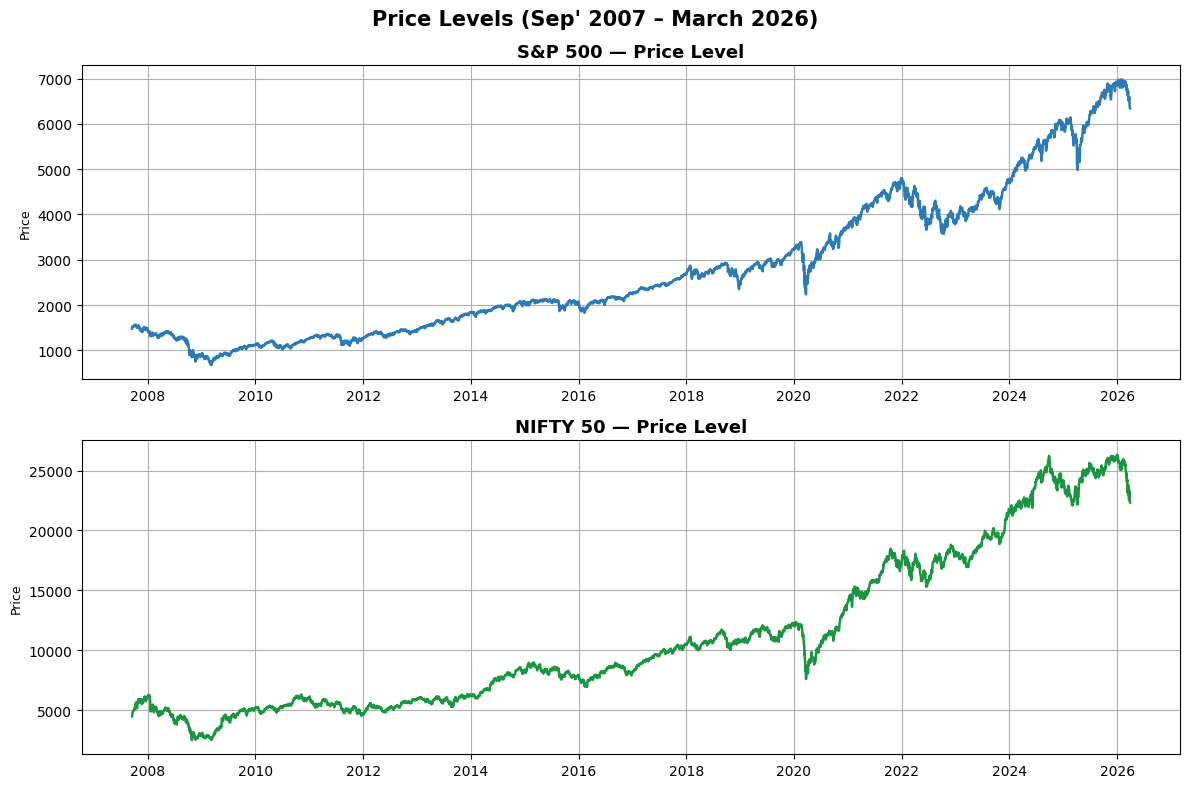

In [9]:
fig, ax = plt.subplots(2, figsize=(12, 8), sharex=False)

series_info = [
    ("SP500",  "#2c7bb6", "S&P 500"),
    ("NIFTY",  "#1a9641", "NIFTY 50"),
]

for i, (col, color, title) in enumerate(series_info):
    ax[i].plot(data.index, data[col], color=color, linewidth=1.8)
    ax[i].set_title(f"{title} — Price Level", fontsize=13, fontweight='bold')
    ax[i].set_ylabel("Price", fontsize=9)
    ax[i].grid(True)

plt.suptitle("Price Levels (Sep' 2007 – March 2026)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observations
Both series show a strong upward trend over time \
This suggests non-stationarity, which needs to be formally tested

----

### ADF Test (on Price)

In [10]:
run_adf_test(data[['SP500', 'NIFTY']])

,Variable,ADF Statistic,P-Value,Stationary (5%)
0,SP500,1.151300,0.995632,No
1,NIFTY,0.217500,0.973226,No


#### Interpretation

Both SP500 and NIFTY are non-stationary at levels \
This is consistent with typical financial time series

----

### Convert To Returns

In [11]:
bivariate = transform_to_returns(data[['SP500', 'NIFTY']])
bivariate.head()

,SP500,NIFTY
Date,,
2007-09-18,0.028790,0.011404
2007-09-19,0.006068,0.040130
2007-09-20,-0.006746,0.003207
2007-09-21,0.004598,0.018780
2007-09-24,-0.005270,0.019377


---

### ADF Test (on Returns)

In [12]:
run_adf_test(bivariate[['SP500', 'NIFTY']])

,Variable,ADF Statistic,P-Value,Stationary (5%)
0,SP500,-16.699000,0.000000,Yes
1,NIFTY,-21.169200,0.000000,Yes


#### Interpretation
Both series become stationary after converting to returns \
This confirms suitability for further time series modeling

----

### Cointegration Test

Both SP500 and NIFTY are non-stationary in levels but stationary in first differences (I(1)). When series share the same order of integration, cointegration testing is required to determine whether a linear combination of them is stationary.

This allows us to identify the presence of a long-run equilibrium relationship despite individual non-stationarity.

In [13]:
results, lag = cointegration_test(
    data[['SP500', 'NIFTY']],
    maxlags=20,
    criteria='bic'
)

results.head()

Selected Lag (BIC): 3


,Hypothesis,Trace Statistic,Critical Value (5%),Reject H0?
0,r ≤ 0,17.198000,15.494300,Yes
1,r ≤ 1,0.003800,3.841500,No


#### Cointegration Test Interpretation

The Johansen trace test rejects the null hypothesis of no cointegration (r ≤ 0), but fails to reject the null of at most one cointegrating relationship (r ≤ 1).

This indicates the presence of exactly one cointegrating vector between SP500 and NIFTY.

#### Meaning

The two markets share a single long-run equilibrium relationship, implying that any deviation from this equilibrium is temporary and will be corrected over time.

---

### Cointegration Rank

In [14]:
rank = sum(results["Reject H0?"] == "Yes")
print(f"Cointegration Rank: {rank}")
print("-" * 25)

Cointegration Rank: 1
-------------------------


The cointegration rank tells us how many independent long-run equilibrium relationships exist between the variables.

It is essential for specifying the correct model:
- If rank = 0 → no long-run relationship (use VAR)
- If rank ≥ 1 → long-run relationship exists (use VECM)

Thus, identifying the rank ensures that the model properly captures both long-run equilibrium and short-run dynamics.

---

### Final Interpretation

The Johansen test confirms the presence of one cointegrating relationship between SP500 and NIFTY, indicating a stable long-run equilibrium linkage.

Despite short-term fluctuations, the two markets exhibit a tendency to move together over time, with deviations being temporary and mean-reverting.

## Objective 1 – Result
### Do US and Indian markets move together in the long run?
### **Yes** — the markets are cointegrated, indicating a stable long-run equilibrium relationship.

---
---

## Objective 2: Short-run Dynamics between US and Indian Markets

To examine short-run interactions, we estimate a Vector Error Correction Model (VECM), which is a specialized econometric model designed for analyzing non-stationary time series data that share a common long-run equilibrium (cointegration).

### Model Specification

In [15]:
vecm = VECM(
    data[['SP500', 'NIFTY']],
    k_ar_diff=lag-1,   # selected from Johansen test
    coint_rank=1       # from cointegration result
)

vecm_fit = vecm.fit()
print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation SP500
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.SP500      -0.0694      0.015     -4.685      0.000      -0.098      -0.040
L1.NIFTY      -0.0076      0.004     -1.763      0.078      -0.016       0.001
L2.SP500       0.0516      0.015      3.356      0.001       0.021       0.082
L2.NIFTY      -0.0031      0.004     -0.747      0.455      -0.011       0.005
Det. terms outside the coint. relation & lagged endog. parameters for equation NIFTY
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.SP500       1.0302      0.051     20.111      0.000       0.930       1.131
L1.NIFTY      -0.0912      0.015     -6.143      0.000      -0.120      -0.062
L2.SP500       0.3012      0.053      5.

### Granger Causality Test

In [16]:
granger_test(vecm_fit, 'SP500', 'NIFTY')


Granger Causality Test: SP500 → NIFTY
------------------------------------------------------------
Null Hypothesis : SP500 does NOT Granger-cause NIFTY
Test Statistic  : 140.214
Critical Value  : 2.606
P-value         : 0.00000
Conclusion      : Reject H0 (Significant at 5%)


In [17]:
granger_test(vecm_fit, 'NIFTY', 'SP500')


Granger Causality Test: NIFTY → SP500
------------------------------------------------------------
Null Hypothesis : NIFTY does NOT Granger-cause SP500
Test Statistic  : 0.600
Critical Value  : 2.606
P-value         : 0.61498
Conclusion      : Fail to reject H0


---
#### Interpretation

The results show that SP500 Granger-causes NIFTY, while NIFTY does not Granger-cause SP500.

This indicates a unidirectional relationship, where movements in the US market significantly influence the Indian market in the short run, but not vice versa.

----

## Objective 2 – Result
### Does the US market affect the Indian market in the short run?
### **Yes** — there is strong evidence that the US market drives short-run movements in the Indian market.
---
---

## Objective 3: Role of Global Macro-Financial Factors

To examine the short-run influence of global macro-financial variables, a VAR model is estimated using:
1. **Equity returns:** S&P 500, NIFTY 50
2. **Global factors:**
    - VIX (market uncertainty)
    - Brent crude oil prices
    - US Dollar Index (DXY)


Granger causality tests are conducted to evaluate both:
- Individual effects of each macro variable
- Joint effects of all macro variables

### Data preparation

In [18]:
# Convert price series to returns
returns = transform_to_returns(
    data[['SP500', 'NIFTY', 'BRENT', 'DXY']]
)

# Add VIX
df_var = returns.copy()
df_var['VIX'] = data['VIX'].loc[df_var.index]

df_var = df_var.dropna()
df_var.head()

,SP500,NIFTY,BRENT,DXY,VIX
Date,,,,,
2007-09-18,0.028790,0.011404,0.007893,-0.006418,20.350000
2007-09-19,0.006068,0.040130,0.011278,0.001136,20.030001
2007-09-20,-0.006746,0.003207,0.007870,-0.009121,20.450001
2007-09-21,0.004598,0.018780,0.002652,0.000254,19.000000
2007-09-24,-0.005270,0.019377,-0.004930,-0.000891,19.370001


### Model Estimation

In [19]:
model = VAR(df_var)

lag_selection = model.select_order(maxlags=10)
print(lag_selection.summary())

lag = lag_selection.bic

var_fit = model.fit(lag)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -31.66      -31.65   1.779e-14      -31.66
1       -35.88     -35.84*   2.620e-16      -35.86
2       -35.90      -35.83   2.564e-16      -35.87
3       -35.91      -35.81   2.528e-16     -35.88*
4       -35.92      -35.78   2.515e-16      -35.87
5       -35.93      -35.76   2.485e-16      -35.87
6       -35.94      -35.73   2.463e-16      -35.87
7       -35.94      -35.70   2.456e-16      -35.86
8       -35.95      -35.67   2.446e-16      -35.85
9       -35.95      -35.64   2.443e-16      -35.84
10     -35.95*      -35.61  2.429e-16*      -35.83
--------------------------------------------------


#### Reason to use VAR

All variables are stationary in returns, making VAR suitable to capture interdependencies and short-run dynamics across multiple time series.

----

### Granger Causality Tests

#### Impact on SP500

In [20]:
granger_test(var_fit, 'VIX', 'SP500')
granger_test(var_fit, 'BRENT', 'SP500')
granger_test(var_fit, 'DXY', 'SP500')
granger_test(var_fit, ['VIX', 'BRENT', 'DXY'], 'SP500')


Granger Causality Test: VIX → SP500
------------------------------------------------------------
Null Hypothesis : VIX does NOT Granger-cause SP500
Test Statistic  : 0.449
Critical Value  : 3.842
P-value         : 0.50295
Conclusion      : Fail to reject H0

Granger Causality Test: BRENT → SP500
------------------------------------------------------------
Null Hypothesis : BRENT does NOT Granger-cause SP500
Test Statistic  : 3.573
Critical Value  : 3.842
P-value         : 0.05873
Conclusion      : Fail to reject H0

Granger Causality Test: DXY → SP500
------------------------------------------------------------
Null Hypothesis : DXY does NOT Granger-cause SP500
Test Statistic  : 0.618
Critical Value  : 3.842
P-value         : 0.43196
Conclusion      : Fail to reject H0

Granger Causality Test: VIX, BRENT, DXY → SP500
------------------------------------------------------------
Null Hypothesis : VIX, BRENT, DXY does NOT Granger-cause SP500
Test Statistic  : 1.483
Critical Value  : 2.60

#### Summary of Impact on the US Market (S&P 500) 

##### Individual Effects

| Factor        | Result                         | Interpretation                      |
| ------------- | ------------------------------ | ----------------------------------- |
| VIX → SP500   | Not significant              | Volatility does not predict returns |
| BRENT → SP500 | Not significant              | Weak oil influence                  |
| DXY → SP500   | Not significant              | Dollar has no predictive effect     |

##### Joint Effect

| Test                      | Result            |
| ------------------------- | ----------------- |
| (VIX, BRENT, DXY) → SP500 | Not significant |


#### Interpretation

The results indicate that global macro-financial variables do not significantly influence US equity returns in the short run.

##### This suggests:
- The US market is internally driven
- It acts as a global leader rather than a follower
- External macro shocks are either:
    - Already priced in
    - Or absorbed quickly

---

#### Impact on NIFTY

In [21]:
granger_test(var_fit, 'VIX', 'NIFTY')
granger_test(var_fit, 'BRENT', 'NIFTY')
granger_test(var_fit, 'DXY', 'NIFTY')
granger_test(var_fit, ['VIX', 'BRENT', 'DXY'], 'NIFTY')


Granger Causality Test: VIX → NIFTY
------------------------------------------------------------
Null Hypothesis : VIX does NOT Granger-cause NIFTY
Test Statistic  : 2.448
Critical Value  : 3.842
P-value         : 0.11772
Conclusion      : Fail to reject H0

Granger Causality Test: BRENT → NIFTY
------------------------------------------------------------
Null Hypothesis : BRENT does NOT Granger-cause NIFTY
Test Statistic  : 17.848
Critical Value  : 3.842
P-value         : 0.00002
Conclusion      : Reject H0 (Significant at 5%)

Granger Causality Test: DXY → NIFTY
------------------------------------------------------------
Null Hypothesis : DXY does NOT Granger-cause NIFTY
Test Statistic  : 0.602
Critical Value  : 3.842
P-value         : 0.43767
Conclusion      : Fail to reject H0

Granger Causality Test: VIX, BRENT, DXY → NIFTY
------------------------------------------------------------
Null Hypothesis : VIX, BRENT, DXY does NOT Granger-cause NIFTY
Test Statistic  : 6.625
Critical 

#### Summary of Impact on the Indian Market (NIFTY) 

##### Individual Effects

| Factor            | Result            | Interpretation              |
| ----------------- | ----------------- | --------------------------- |
| VIX → NIFTY       | Not significant | No direct fear transmission |
| **BRENT → NIFTY** | Significant     | Strong oil sensitivity      |
| DXY → NIFTY       | Not significant | Limited currency effect     |


###### Joint Effect

| Test                      | Result        |
| ------------------------- | ------------- |
| (VIX, BRENT, DXY) → NIFTY | Significant |



#### Interpretation

The Indian market exhibits significant sensitivity to global macroeconomic conditions, particularly:
- **Oil prices (Brent crude)**

##### This reflects:

- India’s dependence on oil imports
- Exposure to global cost shocks

The joint significance further indicates that:
> Even if individual variables (like VIX or DXY) are not significant alone, their combined effect matters

----

### Final Verdict

Interpretation

The results indicate that global macro-financial variables do not significantly influence the US market in the short run.

In contrast, the Indian market shows sensitivity to global factors, particularly BRENT oil prices, which exhibit a significant causal impact. Additionally, the joint effect of VIX, BRENT, and DXY is significant for NIFTY.

This suggests that while the US market remains relatively self-driven, the Indian market is more exposed to external macro-financial conditions.

---

## Objective 3 – Result
### Do global macro-financial factors influence equity markets?
### **Yes** — global factors significantly influence the Indian market, while the US market remains largely unaffected in the short run.

---
---

## Objective 4: Shock Transmission from US to Indian Market

To understand how shocks in the US market affect the Indian market over time, we use Impulse Response Functions (IRF) based on the VECM model.

### Impulse Response Function (IRF)

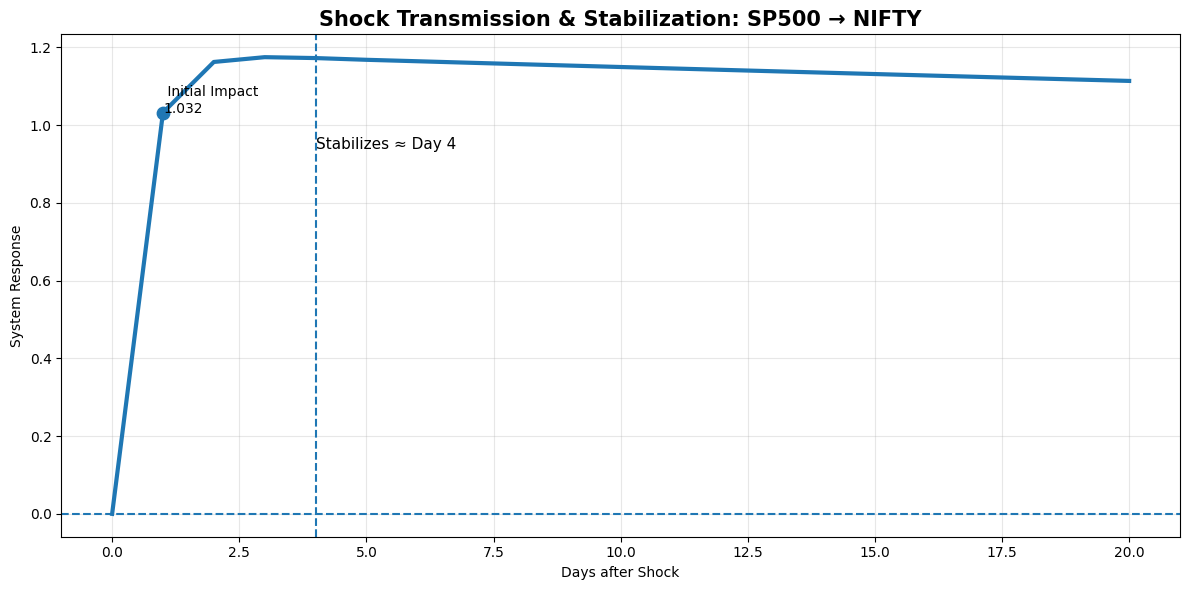

In [22]:
plot_irf_relationship(vecm_fit, 'SP500', 'NIFTY', steps=20)

#### Interpretation

A positive shock in the SP500 generates an immediate and strong response in the NIFTY, with the impact peaking within the first few periods.

The response stabilizes around day 3–4, after which the effect gradually declines but remains positive, indicating persistence.

#### Meaning
The Indian market reacts quickly to US market shocks \
The effect is strong in the short run \
Adjustment is smooth and stabilizes within a few days \
The positive response suggests direct transmission of global market sentiment

---

## Objective 4 – Result
### How quickly does India absorb shocks from the US market?
### India responds rapidly to US market shocks, with effects peaking early and stabilizing within a few days.

---
---

## Objective 5: Asymmetric and Nonlinear Response of Indian Market
To examine whether the Indian market reacts differently to US market movements, we analyze both the direction (positive vs negative) and magnitude (small vs large) of shocks.

### Asymmetric Response (Positive vs Negative Shocks)

In [23]:
returns = transform_to_returns(data[['SP500', 'NIFTY']])
df_asym = returns.copy()

df_asym['SP500_pos'] = df_asym['SP500'].clip(lower=0)
df_asym['SP500_neg'] = df_asym['SP500'].clip(upper=0)

X = df_asym[['SP500_pos', 'SP500_neg']]
X = sm.add_constant(X)

y = df_asym['NIFTY']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  NIFTY   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     206.4
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           9.97e-87
Time:                        19:00:58   Log-Likelihood:                 14464.
No. Observations:                4833   AIC:                        -2.892e+04
Df Residuals:                    4830   BIC:                        -2.890e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      3.372      0.0

---
#### Interpretation

Both positive and negative movements in the US market have a statistically significant impact on the Indian market, as indicated by highly significant coefficients (p < 0.001).

- A 1% increase in the S&P 500 returns is associated with approximately a 0.21% increase in the NIFTY returns
- A 1% decrease in the S&P 500 return is associated with approximately a 0.34% decrease in the NIFTY returns

The larger magnitude of the negative coefficient (0.3428 > 0.2114) indicates a stronger transmission of negative shocks.

#### Market Meaning
The Indian market responds to both upward and downward movements in the US market \
However, downside risk is transmitted more strongly than upside gains \
This reflects asymmetric behavior, where negative global sentiment leads to sharper reactions

----

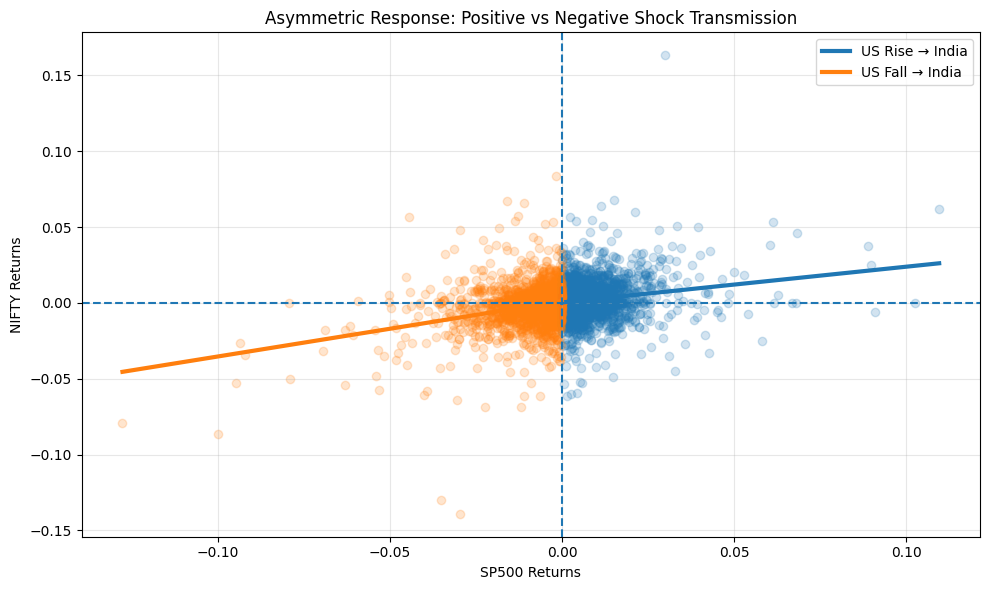

In [24]:
plot_asymmetric_response(returns)

#### Interpretation

The scatter plot shows the relationship between SP500 returns and NIFTY returns, separated into positive (US rises) and negative (US declines) movements.

The fitted regression lines indicate that:
- During positive US returns, NIFTY responds positively, but with a relatively moderate slope
- During negative US returns, the slope is noticeably steeper, indicating a stronger response


#### What this shows
The Indian market reacts to both upward and downward movements in the US \
However, the response to negative shocks is stronger and more pronounced \
The wider spread in the negative region also suggests higher volatility during market declines

#### Insight

This asymmetry reflects that downside movements in the US market transmit more intensely to India, consistent with risk-off behavior where investors react more aggressively to negative news than to positive developments.

---

### Impact of Shock Magnitude (Small vs Large)

In [25]:
returns = transform_to_returns(data[['SP500', 'NIFTY']])

returns['abs_sp'] = returns['SP500'].abs()
threshold = returns['abs_sp'].median()

returns['SP_small'] = returns['SP500'].where(returns['abs_sp'] < threshold, 0)
returns['SP_large'] = returns['SP500'].where(returns['abs_sp'] >= threshold, 0)

X = returns[['SP_small', 'SP_large']]
X = sm.add_constant(X)

y = returns['NIFTY']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  NIFTY   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     199.4
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           6.34e-84
Time:                        19:00:58   Log-Likelihood:                 14458.
No. Observations:                4833   AIC:                        -2.891e+04
Df Residuals:                    4830   BIC:                        -2.889e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.420      0.1

---
#### Interpretation

Both small and large US market shocks have a statistically significant impact on the Indian market.
- A 1% change in small US shocks leads to approximately a 0.26% change in NIFTY returns
- A 1% change in large US shocks leads to approximately a 0.28% change in NIFTY returns

The coefficient for large shocks (0.2825) is slightly higher than that for small shocks (0.2603), and is estimated with much higher precision (very high t-statistic).

#### What this shows
The Indian market responds to both small and large movements in the US \
However, larger shocks have a stronger and more reliable impact \
The higher statistical significance of large shocks indicates more consistent transmission during high-impact periods

---

### Visualization: Small vs Large Shocks

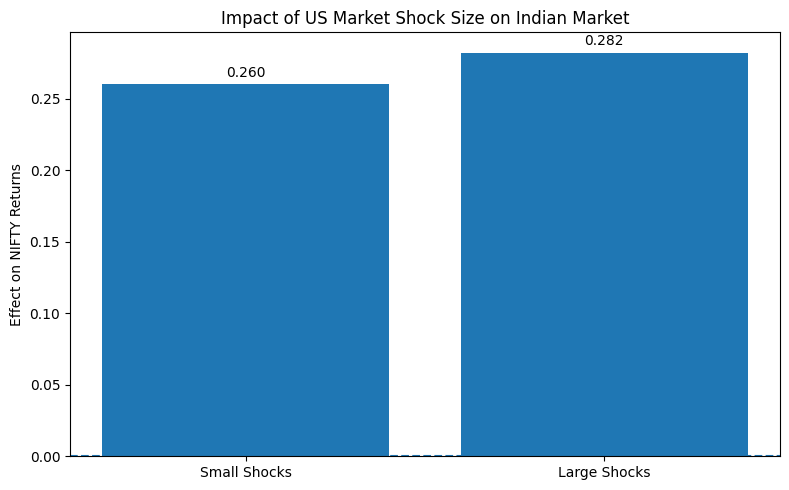

In [26]:
# Extract coefficients
coef_small = model.params['SP_small']
coef_large = model.params['SP_large']

labels = ['Small Shocks', 'Large Shocks']
values = [coef_small, coef_large]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

# Add values on top
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.title("Impact of US Market Shock Size on Indian Market")
plt.ylabel("Effect on NIFTY Returns")

plt.axhline(0, linestyle='--')

plt.tight_layout()
plt.show()

#### Interpretation

The bar chart shows that both small and large US market shocks have a positive and statistically significant impact on the Indian market.
- Small shocks lead to an approximate 0.26% change in NIFTY returns
- Large shocks lead to a higher 0.28% change in NIFTY returns

The higher coefficient for large shocks indicates that stronger US market movements result in a stronger response in the Indian market.

#### Meaning
The Indian market reacts to all types of US market movements \
However, the response intensifies with the magnitude of the shock \
This reflects a nonlinear transmission mechanism, where larger shocks carry greater influence

----

## Objective 5 – Result
### Does India react differently to US market movements?
### **Yes** — the Indian market exhibits both asymmetry and nonlinear response, reacting more strongly to negative shocks and large movements in the US market.

---
---

## Objective 6: Market Dynamics During the Israel–US vs Iran Conflict

To examine how extreme geopolitical events affect market relationships, we focus on the period from February 28 to March 31, 2026, corresponding to the outbreak and escalation of the Israel–US vs Iran war.

This conflict began with coordinated US–Israel strikes on Iran on February 28, leading to significant geopolitical instability and global market disruptions.

### Model Specification

In [27]:
returns = transform_to_returns(data[['SP500','NIFTY','BRENT','VIX']])

returns['crisis'] = 0
returns.loc['2026-02-28':, 'crisis'] = 1

returns['SP500_crisis'] = returns['SP500'] * returns['crisis']
returns['BRENT_crisis'] = returns['BRENT'] * returns['crisis']
returns['VIX_crisis'] = returns['VIX'] * returns['crisis']
returns['NIFTY_crisis'] = returns['NIFTY'] * returns['crisis']

### Effect on NIFTY in Crisis

In [28]:
X = returns[['SP500_crisis','BRENT_crisis','VIX_crisis']]
X = sm.add_constant(X)

y = returns['NIFTY_crisis']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           NIFTY_crisis   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     75.48
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.05e-47
Time:                        19:00:58   Log-Likelihood:                 26340.
No. Observations:                4833   AIC:                        -5.267e+04
Df Residuals:                    4829   BIC:                        -5.265e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.865e-05    1.5e-05     -1.246   

---
#### Interpretation (Impact on India)

All three variables are statistically significant during the crisis period, indicating strong transmission effects.
- A 1% increase in SP500 returns during the conflict period leads to a 0.31% increase in NIFTY returns, indicating a strong dependence
- A 1% increase in BRENT returns leads to a 0.049% decrease in NIFTY returns, reflecting the negative impact of rising oil prices
- A 1% increase in VIX leads to a 0.039% increase in NIFTY returns, indicating heightened sensitivity to volatility

#### What this shows
The influence of the US market on India becomes stronger during crisis periods \
Rising oil prices have a negative effect, reflecting cost pressures on the Indian economy \
Volatility (VIX) plays a significant role, amplifying market movements

#### Insight

This indicates that during crisis periods, the Indian market becomes more externally driven, with stronger dependence on global markets and macro-financial conditions.

----

### Effect on SP500 in Crisis

In [29]:
X = returns[['NIFTY_crisis','BRENT_crisis','VIX_crisis']]
X = sm.add_constant(X)

y = returns['SP500_crisis']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           SP500_crisis   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     4873.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:00:58   Log-Likelihood:                 31999.
No. Observations:                4833   AIC:                        -6.399e+04
Df Residuals:                    4829   BIC:                        -6.396e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -6.126e-06   4.64e-06     -1.320   

---
#### Interpretation

All variables are statistically significant during the crisis period, indicating strong relationships with the US market.
- A 1% increase in NIFTY returns during crisis leads to only a 0.03% increase in SP500 returns, indicating a very weak effect
- A 1% increase in BRENT returns leads to a 0.036% decrease in SP500 returns, showing a negative impact
- A 1% increase in VIX leads to a 0.074% decrease in SP500 returns, indicating a strong negative relationship with market volatility

#### What this shows
The influence of India on the US market is economically small, despite being statistically significant \
Oil prices negatively affect both markets, but the impact is more pronounced on the US here \
Volatility (VIX) has a strong negative effect on the US market, reflecting risk-off behavior

#### Insight

Even during crisis periods, the US market remains dominant and largely independent, while being strongly affected by global risk factors such as volatility and oil prices.

## Objective 6 – Result
### Does the relationship change during the Israel–US vs Iran war period?
### **Yes** — during the conflict period, global linkages strengthen, with increased US influence on India and heightened sensitivity to oil prices and volatility, while reverse influence remains economically weak.

---
---

# Final Conclusion

This study analyzes the relationship between the US and Indian equity markets using a comprehensive time series framework, capturing both long-run equilibrium and short-run dynamics.

The findings provide strong evidence of a long-run cointegrating relationship, indicating that the two markets move together over time despite short-term deviations. In the short run, the US market emerges as the dominant driver, significantly influencing Indian market movements, while the reverse impact remains economically negligible.

The results further show that the Indian market is more sensitive to global macro-financial factors, particularly oil prices and market volatility, whereas the US market remains relatively less affected by external conditions.

Additionally, the analysis reveals clear asymmetry and nonlinearity in market behavior. The Indian market reacts more strongly to negative shocks and large movements in the US market, emphasizing the role of downside risk and heightened market stress.

During periods of crisis, these effects become more pronounced. Shock transmission from the US intensifies, and the Indian market exhibits increased sensitivity to global risk indicators, highlighting the vulnerability of emerging markets during times of uncertainty.

## Key Takeaways
US and Indian markets are cointegrated in the long run
The US market drives short-run dynamics
The Indian market is more sensitive to global factors
Negative and large shocks have stronger transmission effects
Crisis periods intensify global interdependence

## Final Insight
> The US market functions as a global driver, while the Indian market acts as a responsive system, exhibiting stronger reactions during periods of stress and uncertainty.

---
---